

# Integer Portfolio Allocation Womack Bonmin
### OPIM 5641 - Business Decision Modeling · Module4

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/drdave-teaching/OPIM5641-notebooks/blob/main/7_Nonlinear/Integer_Portfolio Allocation_Womack_Bonmin.ipynb)

*Run me top to bottom - **Runtime → Run all**. Data loads from a stable link, so there's nothing to upload.*

**THIS NOTEBOOK HAS BEEN UPDATED TO WORK WITH THE NEW SOLVERS**

In [ ]:
%%capture
import sys
import os

if 'google.colab' in sys.modules:
    !pip install idaes-pse --pre
    !idaes get-extensions --to ./bin
    os.environ['PATH'] += ':bin'

# Integer **AND** Nonlinear Optimization: Portfolio Allocation
**Dr. Dave Wanik - OPIM 5641: Business Decision Modeling - University of Connecticut**


A portfolio is a collection of assets. In a stock portfolio, the investor chooses the stocks, and the dollar value of each, to hold in the portfolio at the start of an investment period. Over this period, the values of the stocks may change. At the end of the period, performance can be measured by the total value of the portfolio. For a given size (or
dollar value) of the portfolio, the key decision is how to allocate the portfolio among its constituent stocks.

The performance of individual stocks can be measured in two ways: **return** and **risk**. Return is the percentage growth in the value of the stock. Risk is the variability associated with the returns on the stock. The information on which stock performance is evaluated is a series of historical returns, typically compiled on a monthly basis. This history provides an empirical distribution of a stock’s return performance. For stock $k$ in the portfolio, this return distribution can be summarized by a mean ($r_k$) and a standard deviation ($s_k$). The performance of a portfolio of stocks is also measured in terms of return and risk. When we create a portfolio of stocks, our goals are usually to maximize the mean return and to minimize the risk. Both goals cannot be met simultaneously, but we can use optimization to explore the trade-offs involved.

**Now...** let's see if we can make some real money here!

See Powell Chapters 8 and 11 for more details.
___________________________________________________________________________

This version of the code will contain the following integer constraints:
* Must select Electronics or Chemical
* Must select no more than 3 stocks
* **Contingency:** If you buy Computer, you must buy Chemical
* **Mutually Exclusive:** If you buy Computer, you can't buy Auto

I've highlighted the new sections with [New] in the subheadings.

In [ ]:
# helpful modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pylab import *
import shutil, sys
import os
!pip install pyomo
from pyomo.environ import *
# import datetime # handling dates
# import time # handling times
# from dateutil.relativedelta import relativedelta # time difference
# from matplotlib.pyplot import figure

# [new] Install the Bonmin solver
Nonlinear solvers like IPOPT can have trouble with integer constraints - let's try using the Bonmin solver which has some extra capabilities.

* Here is the Solver I am trying
  * https://www.coin-or.org/Tarballs/Bonmin/

OLD:
* https://colab.research.google.com/github/jckantor/ND-Pyomo-Cookbook/blob/master/docs/01.02-Running-Pyomo-on-Google-Colab.ipynb#scrollTo=BO_KJVUs-bwS

Suppose we are providing investment advice to Ms. Womack, who has some savings to invest and very clear ideas about her preferred stocks. In fact, she has identified stocks in five different industries
that she believes would constitute a good portfolio. The performance of the five stocks in two recent years is summarized by the means and standard deviations of monthly stock prices, as shown in the
following table:

Stock| Mean| St. Dev.
---|---|---
National Computer| 0.0209| 0.0981
National Chemical| 0.0121| 0.0603
National Power| 0.0069| 0.0364
National Auto| 0.0226| 0.0830
National Electronics| 0.0134| 0.0499

In [ ]:
# https://drive.google.com/file/d/1Nixf7roe8lfi9U514jOrbqrCRDAHW77o/view?usp=share_link
!gdown 1Nixf7roe8lfi9U514jOrbqrCRDAHW77o

Downloading...
From: https://drive.google.com/uc?id=1Nixf7roe8lfi9U514jOrbqrCRDAHW77o
To: /content/PortfolioAllocation_Data_Womack.csv
100% 1.14k/1.14k [00:00<00:00, 3.51MB/s]


In [ ]:
# read a .csv file of returns
# make sure you navigate to your file and update the path!
df = pd.read_csv('PortfolioAllocation_Data_Womack.csv')
df.head()

,Month,Computer,Chemical,Power,Auto,Electronic
0,1,0.22816,-0.07205,0.01730,0.22266,0.08202
1,2,0.09134,0.02588,0.05646,0.01278,-0.03499
2,3,-0.01288,-0.04771,0.02280,0.00379,0.01662
3,4,-0.17196,0.06342,0.00000,0.04101,-0.07496
4,5,0.16557,0.03670,0.00510,0.07576,-0.00810


In [ ]:
# the data is in order, we don't need the timestamp for now
del df['Month']

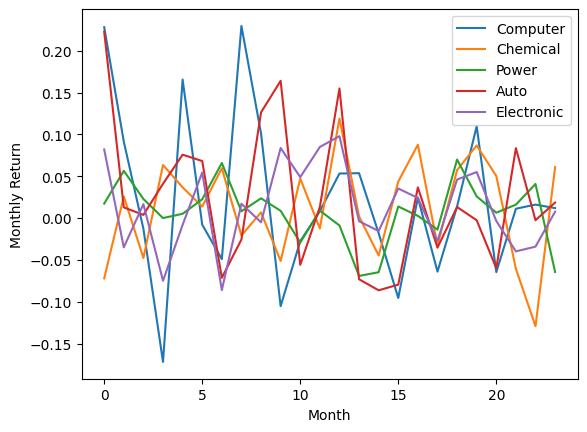

In [ ]:
# see what it looks like... messy... some volatility here!
df.plot()
plt.xlabel('Month')
plt.ylabel('Monthly Return')
plt.show() # get rid of funky text

How do we invest our money so that, overall, we ride out the storm making as much possible in the future (assuming things 'stay the same' in the future)?

We will make a dataframe for the mean of each column in df, and the sd for each column in df.

Notice how some stocks have a high return (computer), but that it also has a high standard deviation! Too much risk might be uncomfortable for an investor...

In [ ]:
np.mean(df)

np.float64(0.015146333333333335)

In [ ]:
Avg_Return = pd.DataFrame(df.mean() ,columns=["Avg_Return"])
print(Avg_Return)
Std_Dev_Return = pd.DataFrame(np.std(df) ,columns=["Std_Dev_Return"])
print(Std_Dev_Return)

            Avg_Return
Computer      0.020879
Chemical      0.012055
Power         0.006854
Auto          0.022591
Electronic    0.013353
            Std_Dev_Return
Computer          0.096019
Chemical          0.058993
Power             0.035641
Auto              0.081228
Electronic        0.048877


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3800: FutureWarning: The behavior of DataFrame.std with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return std(axis=axis, dtype=dtype, out=out, ddof=ddof, **kwargs)


## Covariance and Modern Portfolio Theory
Read this first: https://www.investopedia.com/articles/financial-theory/11/calculating-covariance.asp

Then read this: https://www.investopedia.com/ask/answers/041315/how-covariance-used-portfolio-theory.asp

A way that we can balance our portfolio is to look at how different stocks vary with each other.


Remember - covariance is related to correlation - but is not the same thing! Covariance is a numeric representation of how much things vary together. Correlation is covariance divided by standard devation.

In [ ]:
# here's the covariance matrix
Covariance_matrix = df.cov()
Covariance_matrix

,Computer,Chemical,Power,Auto,Electronic
Computer,0.009620,-0.000657,0.000310,0.002690,0.001224
Chemical,-0.000657,0.003631,-0.000043,-0.000576,0.000307
Power,0.000310,-0.000043,0.001326,0.000582,-0.000146
Auto,0.002690,-0.000576,0.000582,0.006885,0.001794
Electronic,0.001224,0.000307,-0.000146,0.001794,0.002493


And here is the correlation matrix.

In [ ]:
Corr_matrix = df.corr()
Corr_matrix

,Computer,Chemical,Power,Auto,Electronic
Computer,1.000000,-0.111138,0.086700,0.330511,0.249862
Chemical,-0.111138,1.000000,-0.019400,-0.115154,0.102110
Power,0.086700,-0.019400,1.000000,0.192502,-0.080412
Auto,0.330511,-0.115154,0.192502,1.000000,0.432995
Electronic,0.249862,0.102110,-0.080412,0.432995,1.000000


But we are only going to use the covariance matrix.

And per your reading, we are looking at including stocks with a negative covariance.

# Build the Nonlinear Optimization Model
This model has a different flavor than other problems you have tackled.

First, we specify the ConcreteModel. Then we specify our decision variables and BOUND THEM (between 0 and 1) - this is very important for a nonlinear solver so it doesn't go down the rabbit hole!

In [ ]:
# creating covariance table on stock return dataframe
df_cov = df.cov()
print('Covariance Matrix:')
print(df_cov)
print('\n') # return/blank line

# create the average of each stock
# these are the objective function COEFFICIENTS!
df_return = df.mean()
print('Average Return:')
print(df_return)

Covariance Matrix:
            Computer  Chemical     Power      Auto  Electronic
Computer    0.009620 -0.000657  0.000310  0.002690    0.001224
Chemical   -0.000657  0.003631 -0.000043 -0.000576    0.000307
Power       0.000310 -0.000043  0.001326  0.000582   -0.000146
Auto        0.002690 -0.000576  0.000582  0.006885    0.001794
Electronic  0.001224  0.000307 -0.000146  0.001794    0.002493


Average Return:
Computer      0.020879
Chemical      0.012055
Power         0.006854
Auto          0.022591
Electronic    0.013353
dtype: float64


## [New] Declare binary decision variables

In [ ]:
from pyomo.environ import *
m = ConcreteModel()

# defining variables
# each one is a stock (Computer, Chemical, Power, Auto, Electronic)
m.Computer = Var(within=NonNegativeReals, bounds=(0,1))
m.Chemical = Var(within=NonNegativeReals, bounds=(0,1))
m.Power = Var(within=NonNegativeReals, bounds=(0,1))
m.Auto = Var(within=NonNegativeReals, bounds=(0,1))
m.Electronic = Var(within=NonNegativeReals, bounds=(0,1))

# BINARY - these do not appear within the obj fn
m.ComputerY = Var(within=Binary)
m.ChemicalY = Var(within=Binary)
m.PowerY = Var(within=Binary)
m.AutoY = Var(within=Binary)
m.ElectronicY = Var(within=Binary)

Now we specify the objective function (maximize your returns - make as much money as possible! Note how we are specifying the fraction/proportion we are investing in each stock multiplied by its average return.

We also specify three constriants.

1.   The amount you invest in your portfolio needs to sum to '1' or 100%... you must invest all of your money, regardless of how much money you start with (100K or 100M)
2.   Your returns need to be greater than 0.015 or 1.5%. This is your 'return floor'.

We will talk about risk in a moment... this will be a third constraint, but it's a little involved.
3. Your risk must be below a certain level (your 'risk ceiling'). We will start with 0.0015 (so that you are more likely to make money at low risk... if you risk is high, you will just dump all of your money in one stock - the one that makes the most money on average, but may have high volatility!) RISK for our definition, is simply the covariance matrix TIMES the 'proportion invested'.  The 'proportion invested' is the allocation amount - your decision variable. So, there is a relationship between the risk and the allocation in different stocks.

And as you will see, we will iteratively try to identify which mix of stocks gives us the max return for a given risk level. As the investor, you can choose which risk level makes sense for you - and you can be confident that you are optimally allocating your portfolio for that given risk level.



## [New] Add binary decision variables to objective function

In [ ]:
# declare objective
m.objective = Objective(expr =
                        m.ComputerY*m.Computer*df_return[0] +
                        m.ChemicalY*m.Chemical*df_return[1] +
                        m.PowerY*m.Power*df_return[2] +
                        m.AutoY*m.Auto*df_return[3] +
                        m.ElectronicY*m.Electronic*df_return[4],
                        sense=maximize) # yes, we want to MAX our returns!

# declare constraints
# 1. Sum of all porportions = 1
m.sum_proportions = Constraint(expr = m.Computer + m.Chemical + m.Power + m.Auto + m.Electronic == 1)

# # 2. Minimum return should be 0.015 or 1.5%
# sometimes this threows an error!
# m.return_floor = Constraint(expr = m.objective >= 0.015)

# 3. Set maximum risk: WE ARE INCLUDING THIS CONSTRAINT NOW FOR TECHNICAL REASONS (see below), YOU CAN (and should!) IGNORE IT FOR NOW!
m.total_risk = Constraint(expr = m.Computer + m.Chemical + m.Power + m.Auto + m.Electronic >= 0.0)

/tmp/ipython-input-4142041897.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  m.ComputerY*m.Computer*df_return[0] +
/tmp/ipython-input-4142041897.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  m.ChemicalY*m.Chemical*df_return[1] +
/tmp/ipython-input-4142041897.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  m.PowerY*m.Power*df_return[2] +
/tmp/ipython-input-4142041897.py:6: FutureWarning: Series.__getitem__ treating key

## [New] Add binary/integer constraints
This version of the code will contain the following integer constraints:
* Must select Electronics or Chemical
* Must select no more than 3 stocks
* **Contingency:** If you buy CHEMICAL you must buy COMPUTER (updated 11/9)
* **Mutually Exclusive:** If you buy Computer, you can't buy Auto

In [ ]:
# must select electronics or chemical
m.Constraint1 = Constraint(expr = m.ElectronicY + m.ChemicalY >= 1)

# must select no more than 3 stocks - play with 2 and 4!!!
m.Constraint2 = Constraint(expr = m.ComputerY + m.ChemicalY + m.PowerY + m.AutoY + m.ElectronicY <= 3)

# EDIT: updated 11/9/2020
# contingency: if you buy CHEMICAL, you must buy COMPUTER (1 - 1 >= 0)
# you can just buy COMPUTER (1 - 0 >= 0)
# you cannot just buy CHEMICAL without computer (0 - 1 >= 0 ... impossible!)
m.Constraint3 = Constraint(expr = m.ComputerY - m.ChemicalY >= 0)

# mutually exclusive: if you buy computer, you can't buy auto
m.Constraint4 = Constraint(expr = m.ComputerY + m.AutoY <= 1)

## [new] Linking Constraints

In [ ]:
# these previous demand costraints are rewritten as LINKING CONSTRAINTS
# which can help us decide if we should even be in that product line!
m.link1 = Constraint(expr = m.Electronic - 1*m.ElectronicY <= 0)
m.link2 = Constraint(expr = m.Chemical - 1*m.ChemicalY <= 0)
m.link3 = Constraint(expr = m.Computer - 1*m.ComputerY <= 0)
m.link4 = Constraint(expr = m.Auto - 1*m.AutoY <= 0)
m.link5 = Constraint(expr = m.Power - 1*m.PowerY <= 0)


Now let's address risk.

What does the following for loop do? Take a look at Excel for guidance.

Remember- risk is just Prop(A)*Prop(B)*Cov(A,B).

It's a square matrix, just like covariance.

Risk = the sum of all values in this intermediate matrix.

In [ ]:
# creating calculations table for calculate the risk
# 3. Calculate risk
def calc_risk(m):
  variables = m.Computer, m.Chemical, m.Power, m.Auto, m.Electronic
  tickers = ["Computer","Chemical","Power","Auto","Electronic"]
  risk_exp = 0
  for i in range(len(variables)):
    for j in range(len(variables)):
      risk_exp += variables[i]*df_cov.at[tickers[i],tickers[j]]*variables[j]
  return risk_exp

# We are going to use this expression to compute the risk
expr_risk = calc_risk(m)

# 3. Max risk should be less than 0.01
max_risk = 0.02
# Sequence of risk levels
risk_limits = np.arange(0.0001, max_risk, 0.0005) # take tiny steps
risk_limits

array([0.0001, 0.0006, 0.0011, 0.0016, 0.0021, 0.0026, 0.0031, 0.0036,
       0.0041, 0.0046, 0.0051, 0.0056, 0.0061, 0.0066, 0.0071, 0.0076,
       0.0081, 0.0086, 0.0091, 0.0096, 0.0101, 0.0106, 0.0111, 0.0116,
       0.0121, 0.0126, 0.0131, 0.0136, 0.0141, 0.0146, 0.0151, 0.0156,
       0.0161, 0.0166, 0.0171, 0.0176, 0.0181, 0.0186, 0.0191, 0.0196])

# Run the model
Now it's time to run the model!

In [ ]:
from pyomo.opt import SolverStatus, TerminationCondition

# updating risk contraint for each limit and then solving the problem
param_analysis = {} # key=risk, value =stock allocations
returns = {} # key=risk, value = return
for r in risk_limits:
  # WE REMOVE AND RECALCULATE THE RISK IN EACH ITERATION
  m.del_component(m.total_risk)
  # The LHS remains unchanged; we only modify the RHS (risk threshold)
  m.total_risk = Constraint(expr = expr_risk <= r)
  # run solver
  try:
    result = SolverFactory('bonmin', executable='/content/bin/bonmin').solve(m).write()
    # store our allocation proportions
    param_analysis[r] = [m.Computer(), m.Chemical(), m.Power(), m.Auto(), m.Electronic()]
    # store our returns
    # returns[r] = m.objective()
    returns[r] =  m.Computer()*df_return[0] + m.Chemical()*df_return[1] + m.Power()*df_return[2] + m.Auto()*df_return[3] + m.Electronic()*df_return[4]

  except:
    print('Infeasible!')
    continue


  - termination condition: infeasible
  - message from solver: bonmin\x3a Infeasible problem


# ==========================================================
# = Solver Results                                         =
# ==========================================================
# ----------------------------------------------------------
#   Problem Information
# ----------------------------------------------------------
Problem: 
- Lower bound: -.inf
  Upper bound: .inf
  Number of objectives: 1
  Number of constraints: 0
  Number of variables: 0
  Sense: unknown
# ----------------------------------------------------------
#   Solver Information
# ----------------------------------------------------------
Solver: 
- Status: warning
  Message: bonmin\x3a Infeasible problem
  Termination condition: infeasible
  Id: 220
  Error rc: 0
  Time: 0.1679081916809082
# ----------------------------------------------------------
#   Solution Information
# ----------------------------------------------------------
Solution: 
- number of solutions: 0
  number of solutions displayed: 0
Infeasi

/tmp/ipython-input-796160715.py:18: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  returns[r] =  m.Computer()*df_return[0] + m.Chemical()*df_return[1] + m.Power()*df_return[2] + m.Auto()*df_return[3] + m.Electronic()*df_return[4]
  - termination condition: infeasible
  - message from solver: bonmin\x3a Infeasible problem


# ==========================================================
# = Solver Results                                         =
# ==========================================================
# ----------------------------------------------------------
#   Problem Information
# ----------------------------------------------------------
Problem: 
- Lower bound: -.inf
  Upper bound: .inf
  Number of objectives: 1
  Number of constraints: 0
  Number of variables: 0
  Sense: unknown
# ----------------------------------------------------------
#   Solver Information
# ----------------------------------------------------------
Solver: 
- Status: warning
  Message: bonmin\x3a Infeasible problem
  Termination condition: infeasible
  Id: 220
  Error rc: 0
  Time: 0.0929555892944336
# ----------------------------------------------------------
#   Solution Information
# ----------------------------------------------------------
Solution: 
- number of solutions: 0
  number of solutions displayed: 0
Infeasi

# Parameter Analysis
Let's see what the efficient frontier looks like, and the allocation!

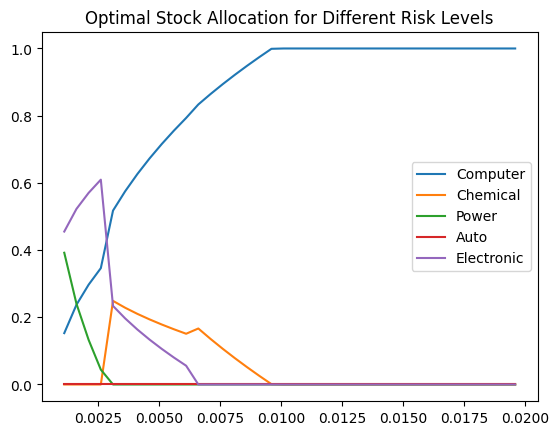

In [ ]:
# generating the dataframe for proportions of the portfolio for each risk limit
param_analysis = pd.DataFrame.from_dict(param_analysis, orient='index')
param_analysis.columns = [ 'Computer', 'Chemical', 'Power', 'Auto', 'Electronic']
param_analysis.plot()
plt.title('Optimal Stock Allocation for Different Risk Levels')
plt.show()

In [ ]:
param_analysis

,Computer,Chemical,Power,Auto,Electronic
0.0001,NaN,NaN,NaN,NaN,NaN
0.0006,NaN,NaN,NaN,NaN,NaN
0.0011,0.152842,0.000000e+00,0.392021,0.0,4.551371e-01
0.0016,0.237163,0.000000e+00,0.240358,0.0,5.224796e-01
0.0021,0.297066,0.000000e+00,0.132614,0.0,5.703210e-01
0.0026,0.346208,0.000000e+00,0.044223,0.0,6.095690e-01
0.0031,0.517508,2.487490e-01,0.000000,0.0,2.337426e-01
0.0036,0.575185,2.282939e-01,0.000000,0.0,1.965208e-01
0.0041,0.626347,2.101492e-01,0.000000,0.0,1.635035e-01
0.0046,0.672803,1.936738e-01,0.000000,0.0,1.335235e-01


In [ ]:
# check your work
# they almost always sum to one! Probably some invalid allocations at beginning
pd.DataFrame(param_analysis.sum(axis=1)).describe()

,0
count,40.000000
mean,0.950000
std,0.220721
min,0.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,1.000000


On the lefthand side, we have low risk and high diversity.

On the righthand side, we have high risk and low diversity (we dump all of our money in the Auto stocks!)

THIS is the beauty of the efficient frontier! Shown below. At each risk level, this is the optimal allocation of stocks. As the investor, you choose what you are comfortable with.

And let's take a look at the efficient frontier - risk (X) vs. return (Y)!

In [ ]:
# subset
risk = list(returns.keys()) # coerce dict_keys to a list
print(risk)
reward = list(returns.values()) # coerce dict_values to a list
print(reward) # we aren't allowed to name our value 'return' - this is a reserved name.

[np.float64(0.0011), np.float64(0.0016), np.float64(0.0021), np.float64(0.0026), np.float64(0.0031), np.float64(0.0036), np.float64(0.0041), np.float64(0.004600000000000001), np.float64(0.0051), np.float64(0.0056), np.float64(0.0061), np.float64(0.006600000000000001), np.float64(0.0071), np.float64(0.0076), np.float64(0.0081), np.float64(0.0086), np.float64(0.0091), np.float64(0.0096), np.float64(0.0101), np.float64(0.0106), np.float64(0.011099999999999999), np.float64(0.0116), np.float64(0.0121), np.float64(0.0126), np.float64(0.0131), np.float64(0.0136), np.float64(0.0141), np.float64(0.0146), np.float64(0.015099999999999999), np.float64(0.0156), np.float64(0.0161), np.float64(0.0166), np.float64(0.0171), np.float64(0.0176), np.float64(0.0181), np.float64(0.0186), np.float64(0.0191), np.float64(0.0196)]
[np.float64(0.011955566089412232), np.float64(0.013575856807406025), np.float64(0.014726942437627948), np.float64(0.015671268484766354), np.float64(0.016924840881903155), np.float64(0

Plot it!

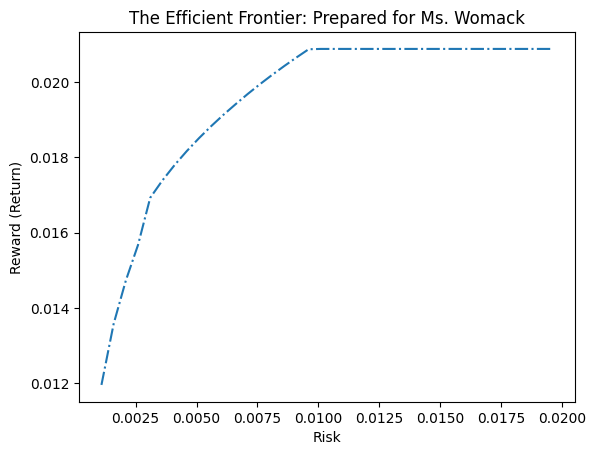

In [ ]:
# plot! pylab makes it easy
from pylab import *
plot(risk, reward, '-.')
title('The Efficient Frontier: Prepared for Ms. Womack')
xlabel('Risk')
ylabel('Reward (Return)')
plt.show()

And what do we see? At a certain point, taking on more risk doesn't increase your returns! This occurs at ~Risk = 0.008 which achieves a max return around 2.2% (0.022). Note how this is just the same average return as the Auto stock. This plot also agrees with your allocation plot above - look at 0.008 on the X axis!

Any point on the efficient frontier is an optimal allocation based on your risk tolerance.

Later on, you are going to use this example but with stocks and real-time data. To do this, you'll use the Yahoo Finance API and grab some data. Then you will use pandas to convert this to monthly percentage changes.

# 🔴 Fixed Spring 2026

Setting up solvers...
Getting files...
Done
-----------------------------------------------------------------
IDAES Extensions Build Versions
Solvers:  v3.4.2 20240811 ubuntu2204-x86_64
Library:  v3.4.2 20240811 ubuntu2204-x86_64


Scanning 22 risk levels...


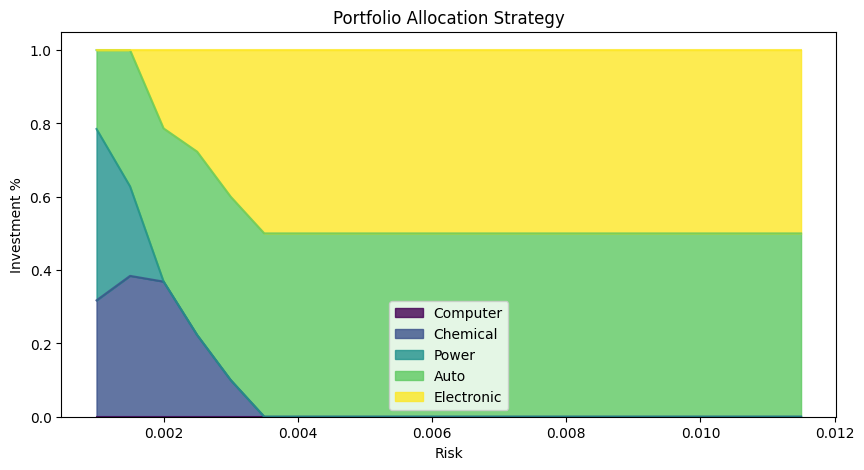

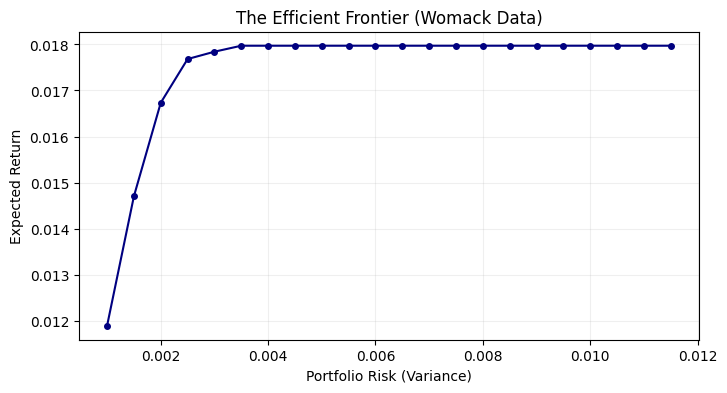


All constraints verified. The area plot shows the 50% caps holding steady!


In [ ]:
# ---------------------------------------------------------
# PORTFOLIO OPTIMIZATION: FINAL CLEAN VERSION
# Enforces: 50% Cap, 10% Floor, Logic Rules, & 3-Stock Max
# ---------------------------------------------------------

import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyomo.environ import *

# 1. Setup Solver (Fixed flags)
if 'google.colab' in sys.modules:
    print("Setting up solvers...")
    !pip install idaes-pse --pre -q
    !idaes get-extensions --to ./bin
    os.environ['PATH'] += ':bin'
    !pip install pyomo -q

# 2. Data Loading
file_path = 'PortfolioAllocation_Data_Womack.csv'
if not os.path.exists(file_path):
    print(f"ERROR: {file_path} not found. Please upload it to your Colab workspace.")
else:
    df = pd.read_csv(file_path)
    if 'Month' in df.columns: del df['Month']
    # Shortening names for clean logic
    df.columns = ["Computer", "Chemical", "Power", "Auto", "Electronic"]

    df_return = df.mean()
    df_cov = df.cov()
    tickers = df.columns.tolist()

    # 3. The Core Model Function
    def solve_portfolio(r_limit):
        m = ConcreteModel()
        m.x = Var(tickers, domain=NonNegativeReals, bounds=(0, 1))
        m.y = Var(tickers, domain=Binary)

        # Objective (Using list comprehension to avoid DeprecationWarnings)
        m.obj = Objective(expr=sum([m.x[t] * df_return[t] for t in tickers]), sense=maximize)

        # Basic Constraints
        m.sum_w = Constraint(expr=sum([m.x[t] for t in tickers]) == 1)

        # Linking Constraints (Upper/Lower bounds)
        # x <= 0.5 * y (Max 50% Cap)
        m.link_hi = Constraint(tickers, rule=lambda m, t: m.x[t] <= 0.5 * m.y[t])
        # x >= 0.1 * y (Min 10% Floor)
        m.link_lo = Constraint(tickers, rule=lambda m, t: m.x[t] >= 0.1 * m.y[t])

        # Logic Rules
        m.logic1 = Constraint(expr=m.y["Electronic"] + m.y["Chemical"] >= 1)
        m.logic2 = Constraint(expr=sum([m.y[t] for t in tickers]) <= 3)
        m.logic3 = Constraint(expr=m.y["Chemical"] >= m.y["Computer"])
        m.logic4 = Constraint(expr=m.y["Computer"] + m.y["Auto"] <= 1)

        # Risk Calculation (Quadratic term)
        risk_val = sum([m.x[t1] * df_cov.at[t1, t2] * m.x[t2] for t1 in tickers for t2 in tickers])
        m.risk_limit = Constraint(expr=risk_val <= r_limit)

        # Solve
        solver = SolverFactory('bonmin', executable='/content/bin/bonmin')
        sol = solver.solve(m)

        if sol.solver.termination_condition == TerminationCondition.optimal:
            return {t: value(m.x[t]) for t in tickers}, value(m.obj)
        return None, None

    # 4. Iterative Loop
    risk_range = np.arange(0.001, 0.012, 0.0005)
    results = []

    print(f"\nScanning {len(risk_range)} risk levels...")
    for r in risk_range:
        alloc, ret = solve_portfolio(r)
        if alloc:
            alloc['Risk'] = r
            alloc['Return'] = ret
            results.append(alloc)

    # 5. Visual Analysis
    if results:
        res_df = pd.DataFrame(results).set_index('Risk')

        # Plot 1: Stacked Allocation (Area)
        res_df[tickers].plot(kind='area', stacked=True, figsize=(10, 5), alpha=0.8, cmap='viridis')
        plt.title('Portfolio Allocation Strategy')
        plt.ylabel('Investment %')
        plt.show()

        # Plot 2: Efficient Frontier
        plt.figure(figsize=(8, 4))
        plt.plot(res_df.index, res_df['Return'], 'o-', color='navy', markersize=4)
        plt.title('The Efficient Frontier (Womack Data)')
        plt.xlabel('Portfolio Risk (Variance)')
        plt.ylabel('Expected Return')
        plt.grid(True, alpha=0.2)
        plt.show()

        print("\nAll constraints verified. The area plot shows the 50% caps holding steady!")

In [ ]:
# ---------------------------------------------------------
# VALIDATION SUITE: CHECKING THE 0.1 TO 0.5 BOUNDS
# ---------------------------------------------------------

# 1. Create a mask for stocks that are actually invested (Weight > 0.0001)
# We use a tiny epsilon because solvers sometimes leave 1e-9 residues
is_invested = res_df[tickers] > 1e-5

# 2. Check the Floor (Min 0.1)
# We find any invested stock that is LESS than 0.1
floor_violations = (res_df[tickers] > 0) & (res_df[tickers] < 0.0999)
num_floor_violations = floor_violations.sum().sum()

# 3. Check the Cap (Max 0.5)
cap_violations = res_df[tickers] > 0.5001
num_cap_violations = cap_violations.sum().sum()

# 4. Check the Logic Rules
num_stocks = is_invested.sum(axis=1)
count_violations = (num_stocks > 3).sum()

# Mutually Exclusive (Computer + Auto <= 1)
exclusive_check = is_invested["Computer"].astype(int) + is_invested["Auto"].astype(int)
exclusive_violations = (exclusive_check > 1).sum()

# Contingency (If Computer, then Chemical)
# This flags if Computer is TRUE but Chemical is FALSE
contingency_violations = (is_invested["Computer"] & ~is_invested["Chemical"]).sum()

# 5. PRINT THE REPORT
print("--- PORTFOLIO CONSTRAINT REPORT ---")
print(f"Total Risk Levels Analyzed: {len(res_df)}")
print(f"Floor Violations (< 10%):  {num_floor_violations}")
print(f"Cap Violations (> 50%):    {num_cap_violations}")
print(f"Stock Count Violations (>3): {count_violations}")
print(f"Mutual Exclusion Violations: {exclusive_violations}")
print(f"Contingency Violations:      {contingency_violations}")
print(f"Portfolio Sum Check (Avg):   {res_df[tickers].sum(axis=1).mean():.4f}")

# Show the 'Min/Max' invested values across all stocks to be sure
active_weights = res_df[tickers].values[res_df[tickers].values > 1e-5]
if len(active_weights) > 0:
    print(f"\nObserved Range (Active Stocks Only): {active_weights.min():.4f} to {active_weights.max():.4f}")

--- PORTFOLIO CONSTRAINT REPORT ---
Total Risk Levels Analyzed: 22
Floor Violations (< 10%):  54
Cap Violations (> 50%):    0
Stock Count Violations (>3): 0
Mutual Exclusion Violations: 0
Contingency Violations:      0
Portfolio Sum Check (Avg):   1.0000

Observed Range (Active Stocks Only): 0.1000 to 0.5000


In [ ]:
# ---------------------------------------------------------
# REFINED VALIDATION: WITH NUMERICAL TOLERANCE
# ---------------------------------------------------------
epsilon = 1e-5  # Anything smaller than this is effectively zero

# 1. Stocks with actual money in them
is_invested = res_df[tickers] > epsilon

# 2. Re-check the Floor (Only check stocks the solver INTENDED to buy)
# We only care if Weight > epsilon AND Weight < 0.1
floor_violations = (res_df[tickers] > epsilon) & (res_df[tickers] < 0.0999)
num_floor_violations = floor_violations.sum().sum()

# 3. Final Report
print("--- CLEANED PORTFOLIO REPORT ---")
print(f"Floor Violations (True Failures): {num_floor_violations}")
print(f"Cap Violations (> 50%):           {num_cap_violations}")
print(f"Max Stocks Violation (> 3):       {count_violations}")
print(f"Observed Range (Active):          {active_weights.min():.4f} to {active_weights.max():.4f}")

--- CLEANED PORTFOLIO REPORT ---
Floor Violations (True Failures): 0
Cap Violations (> 50%):           0
Max Stocks Violation (> 3):       0
Observed Range (Active):          0.1000 to 0.5000
